# 📊 Notebook 1: Exploração e Preparação de Dados

## 🎯 Objetivo deste Notebook

Este notebook implementa as fases de **Data Understanding** e **Data Preparation** da metodologia CRISP-DM aplicada ao projeto de análise de incidentes de IA em serviços financeiros.

### O que este notebook engloba:

1. **Coleta de Dados**: Carregamento do dataset AIID (AI Incident Database)
2. **Exploração Inicial**: Análise da estrutura, tipos de dados e qualidade
3. **Limpeza de Dados**: Tratamento de valores ausentes, duplicatas e inconsistências
4. **Filtragem Temática**: Seleção de incidentes do setor financeiro
5. **Engenharia de Features**: Criação de variáveis derivadas relevantes para análise
6. **Estruturação em Banco SQL**: Criação do banco SQLite com 3+ tabelas relacionadas

---

## 📦 1. Importação de Bibliotecas

**O que faz**: Importa todas as bibliotecas necessárias para processamento de dados, análise exploratória e manipulação de banco de dados.

**Bibliotecas utilizadas**:
- `pandas`: Manipulação de DataFrames e análise de dados
- `numpy`: Operações numéricas
- `sqlite3`: Gerenciamento de banco de dados SQL
- `matplotlib/seaborn`: Visualização de dados
- `re`: Expressões regulares para processamento de texto
- `datetime`: Manipulação de datas

## 📂 2. Carregamento dos Dados

**O que faz**: Carrega o dataset original do AI Incident Database (AIID) do Kaggle.

**Fonte dos dados**: 
- Dataset: AI Incident Database (AIID)
- Origem: https://www.kaggle.com/datasets/konradb/ai-incident-database
- Descrição: Repositório de incidentes documentados de sistemas de IA que causaram danos

**Caso de uso**: Este é o primeiro passo para qualquer análise - precisamos carregar os dados brutos antes de processá-los.

In [40]:
import pandas as pd
# import numpy as np  # Removed as 'np' is not accessed
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3

In [41]:
# Carregando o dataset original
csv_path = '/Users/fabicampanari/Desktop/ai-finance-project/3_Final_Running_Code/data/raw/incidents.csv'
df_original = pd.read_csv(csv_path)

print("="*80)
print("📊 DATASET CARREGADO - INFORMAÇÕES GERAIS")
print("="*80)
print(f"\n✅ Total de incidentes carregados: {len(df_original):,}")
print(f"📋 Total de colunas: {len(df_original.columns)}")
print(f"💾 Tamanho em memória: {df_original.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\n📅 Período dos dados: {df_original['date'].min()} até {df_original['date'].max()}")

📊 DATASET CARREGADO - INFORMAÇÕES GERAIS

✅ Total de incidentes carregados: 514
📋 Total de colunas: 9
💾 Tamanho em memória: 0.24 MB

📅 Período dos dados: 1983-09-26 até 2023-03-31


## 🔍 3. Exploração Inicial dos Dados

**O que faz**: Realiza uma inspeção inicial da estrutura do dataset, identificando tipos de dados, valores ausentes e primeiras características.

**Definição**: A exploração inicial é crucial para entender a "saúde" dos dados - quais campos temos, qual a qualidade, e quais transformações serão necessárias.

**Caso de uso**: Antes de qualquer limpeza ou análise, precisamos entender o que temos em mãos.

In [42]:
# Informações básicas sobre o dataset
print("="*80)
print("📋 ESTRUTURA DO DATASET")
print("="*80)
print("\nColunas disponíveis:")
for i, col in enumerate(df_original.columns, 1):
    print(f"{i:2d}. {col}")

print("\n" + "="*80)
print("📊 INFORMAÇÕES SOBRE TIPOS E VALORES AUSENTES")
print("="*80)
df_original.info()

# Primeiras linhas do dataset
print("\n" + "="*80)
print("👀 PRIMEIRAS 3 LINHAS DO DATASET")
print("="*80)
display(df_original.head(3))

📋 ESTRUTURA DO DATASET

Colunas disponíveis:
 1. _id
 2. incident_id
 3. date
 4. reports
 5. Alleged deployer of AI system
 6. Alleged developer of AI system
 7. Alleged harmed or nearly harmed parties
 8. description
 9. title

📊 INFORMAÇÕES SOBRE TIPOS E VALORES AUSENTES
<class 'pandas.DataFrame'>
RangeIndex: 514 entries, 0 to 513
Data columns (total 9 columns):
 #   Column                                   Non-Null Count  Dtype
---  ------                                   --------------  -----
 0   _id                                      514 non-null    str  
 1   incident_id                              514 non-null    int64
 2   date                                     514 non-null    str  
 3   reports                                  514 non-null    str  
 4   Alleged deployer of AI system            514 non-null    str  
 5   Alleged developer of AI system           514 non-null    str  
 6   Alleged harmed or nearly harmed parties  514 non-null    str  
 7   description    

,_id,incident_id,date,reports,Alleged deployer of AI system,Alleged developer of AI system,Alleged harmed or nearly harmed parties,description,title
0,ObjectId(625763de343edc875fe63a15),23,2017-11-08,"[242,243,244,245,246,247,248,249,250,253,254,2...","[""navya"",""keolis-north-america""]","[""navya"",""keolis-north-america""]","[""navya"",""keolis-north-america"",""bus-passengers""]",A self-driving public shuttle by Keolis North ...,Las Vegas Self-Driving Bus Involved in Accident
1,ObjectId(625763dc343edc875fe63a02),4,2018-03-18,"[629,630,631,632,633,634,635,636,637,638,639,6...","[""uber""]","[""uber""]","[""elaine-herzberg"",""pedestrians""]",An Uber autonomous vehicle (AV) in autonomous ...,Uber AV Killed Pedestrian in Arizona
2,ObjectId(625763db343edc875fe639ff),1,2015-05-19,"[1,2,3,4,5,6,7,8,9,10,11,12,14,15]","[""youtube""]","[""youtube""]","[""children""]",YouTube’s content filtering and recommendation...,Google’s YouTube Kids App Presents Inappropria...


## 🧹 4. Análise de Qualidade dos Dados

**O que faz**: Quantifica valores ausentes, identifica duplicatas e avalia a completude dos dados.

**Definição**: Qualidade de dados refere-se à completude, consistência e acurácia dos dados. Dados de baixa qualidade comprometem análises e modelos.

**Caso de uso**: Identificar problemas de qualidade permite planejar estratégias de limpeza adequadas.

In [43]:
# Análise de valores ausentes
missing_data = pd.DataFrame({
    'Coluna': df_original.columns,
    'Valores_Ausentes': df_original.isnull().sum(),
    'Percentual_%': (df_original.isnull().sum() / len(df_original) * 100).round(2)
}).sort_values('Valores_Ausentes', ascending=False)

print("="*80)
print("🔍 ANÁLISE DE VALORES AUSENTES")
print("="*80)
print(missing_data[missing_data['Valores_Ausentes'] > 0].to_string(index=False))

# Verificação de duplicatas
duplicados = df_original.duplicated(subset=['incident_id']).sum()
print(f"\n{'='*80}")
print(f"🔄 DUPLICATAS: {duplicados} incidentes duplicados encontrados")

# Estatísticas descritivas das colunas numéricas
print(f"\n{'='*80}")
print("📈 ESTATÍSTICAS DESCRITIVAS (COLUNAS NUMÉRICAS)")
print("="*80)
display(df_original.describe())

🔍 ANÁLISE DE VALORES AUSENTES
Empty DataFrame
Columns: [Coluna, Valores_Ausentes, Percentual_%]
Index: []

🔄 DUPLICATAS: 0 incidentes duplicados encontrados

📈 ESTATÍSTICAS DESCRITIVAS (COLUNAS NUMÉRICAS)


,incident_id
count,514.000000
mean,261.824903
std,151.820006
min,1.000000
25%,131.250000
50%,261.500000
75%,393.750000
max,524.000000


## 🎯 5. Filtragem Temática - Setor Financeiro

**O que faz**: Filtra o dataset original para incluir apenas incidentes relacionados ao setor financeiro.

**Definição**: Como o projeto foca em IA no setor financeiro, precisamos filtrar incidentes relevantes usando palavras-chave relacionadas a finanças, bancos, crédito, trading, etc.

**Caso de uso**: Reduzir o escopo do dataset para apenas os incidentes que interessam ao nosso estudo, eliminando ruído de outros setores.

In [44]:
# Definindo palavras-chave para identificar incidentes financeiros
financial_keywords = [
    'finance', 'financial', 'banking', 'bank', 'fintech',
    'credit', 'loan', 'mortgage', 'debt',
    'fraud detection', 'anti-money laundering', 'aml',
    'trading', 'algorithmic trading', 'high-frequency trading', 'stock',
    'investment', 'robo-advisor', 'portfolio',
    'payment', 'transaction', 'card',
    'insurance', 'underwriting', 'risk assessment',
    'wealth management', 'asset management'
]

# Função para verificar se um incidente é do setor financeiro
def is_financial_incident(row):
    """
    Verifica se um incidente pertence ao setor financeiro baseado em keywords.
    
    Parâmetros:
        row: linha do DataFrame contendo title e description
    
    Retorna:
        bool: True se o incidente for financeiro, False caso contrário
    """
    text = str(row.get('title', '')) + ' ' + str(row.get('description', ''))
    text = text.lower()
    
    return any(keyword in text for keyword in financial_keywords)

# Aplicando o filtro
df_finance = df_original[df_original.apply(is_financial_incident, axis=1)].copy()

print("="*80)
print("🎯 RESULTADO DA FILTRAGEM TEMÁTICA")
print("="*80)
print(f"\n📊 Total de incidentes ORIGINAIS: {len(df_original):,}")
print(f"💰 Total de incidentes FINANCEIROS: {len(df_finance):,}")
print(f"📈 Percentual do setor financeiro: {(len(df_finance)/len(df_original)*100):.2f}%")
print(f"\n✅ Dataset filtrado criado com sucesso!")

🎯 RESULTADO DA FILTRAGEM TEMÁTICA

📊 Total de incidentes ORIGINAIS: 514
💰 Total de incidentes FINANCEIROS: 31
📈 Percentual do setor financeiro: 6.03%

✅ Dataset filtrado criado com sucesso!


## 🛠️ 6. Limpeza e Padronização de Dados

**O que faz**: Realiza a limpeza dos dados filtrados, incluindo:
- Conversão de datas para formato padrão
- Extração do ano
- Tratamento de valores ausentes
- Criação de campo de texto consolidado

**Definição**: Limpeza de dados é o processo de detectar e corrigir (ou remover) registros corrompidos, incompletos ou irrelevantes de um dataset.

**Caso de uso**: Garantir que os dados estejam em formato adequado para análise e modelagem.

In [45]:
# Renomeando colunas para padrão consistente
df_finance = df_finance.rename(columns={
    'date': 'occurred_date',
    'description': 'summary',
    'Alleged deployer of AI system': 'deployer',
    'Alleged developer of AI system': 'developer',
    'Alleged harmed or nearly harmed parties': 'harmed_parties'
})

# Convertendo datas
df_finance['occurred_date'] = pd.to_datetime(df_finance['occurred_date'], errors='coerce')
df_finance['year'] = df_finance['occurred_date'].dt.year

# Criando campo de texto consolidado (title + summary)
df_finance['text'] = (df_finance['title'].fillna('') + ' ' + 
                      df_finance['summary'].fillna('')).str.lower().str.strip()

# Removendo duplicatas
df_finance = df_finance.drop_duplicates(subset=['incident_id'], keep='first')

# Preenchendo valores ausentes essenciais
df_finance['title'] = df_finance['title'].fillna('No title')
df_finance['summary'] = df_finance['summary'].fillna('No description')

print("="*80)
print("✅ LIMPEZA CONCLUÍDA")
print("="*80)
print(f"\n📊 Total de registros após limpeza: {len(df_finance):,}")
print(f"📅 Período coberto: {df_finance['year'].min():.0f} - {df_finance['year'].max():.0f}")
print(f"\n🔍 Amostra de dados limpos:")
display(df_finance[['incident_id', 'occurred_date', 'year', 'title']].head(3))

✅ LIMPEZA CONCLUÍDA

📊 Total de registros após limpeza: 31
📅 Período coberto: 2003 - 2023

🔍 Amostra de dados limpos:


,incident_id,occurred_date,year,title
9,10,2014-08-14,2014,Kronos Scheduling Algorithm Allegedly Caused F...
35,28,2010-05-08,2010,2010 Market Flash Crash
60,53,2016-03-31,2016,Biased Google Image Results


## 🎨 7. Engenharia de Features - Variáveis Derivadas

**O que faz**: Cria variáveis categóricas derivadas a partir do texto dos incidentes, essenciais para análise de gestão de risco em IA financeira.

**Definição**: Feature engineering é o processo de usar conhecimento de domínio para criar novas variáveis (features) que tornam os algoritmos de ML mais eficazes.

**Variáveis criadas**:
1. `application_type`: Tipo de aplicação de IA (credit_scoring, fraud_detection, trading, etc.)
2. `incident_type`: Natureza do incidente (viés algorítmico, falha operacional, etc.)
3. `customer_segment`: Segmento de cliente afetado (varejo, PME, corporativo)
4. `severity_level`: Nível de severidade (baixo, médio, alto, crítico)
5. Flags binários de governança (investigação regulatória, multas, mudanças de política)

**Caso de uso**: Estas variáveis permitem análises específicas de gestão de risco e são fundamentais para responder às questões de pesquisa do projeto.

In [46]:
# 7.1 - APPLICATION TYPE (Tipo de Aplicação)
def classify_application_type(text):
    """
    Classifica o tipo de aplicação financeira de IA baseado no texto.
    """
    text = text.lower()
    
    if any(kw in text for kw in ['credit scor', 'loan', 'lending', 'mortgage', 'credit decision', 'credit approval']):
        return 'credit_scoring'
    elif any(kw in text for kw in ['fraud', 'aml', 'anti-money laundering', 'suspicious transaction']):
        return 'fraud_detection'
    elif any(kw in text for kw in ['trading', 'algorithmic trading', 'high-frequency', 'flash crash', 'market']):
        return 'algorithmic_trading'
    elif any(kw in text for kw in ['robo-advisor', 'robo advisor', 'investment advisor', 'portfolio management']):
        return 'robo_advisor'
    elif any(kw in text for kw in ['risk assessment', 'underwriting', 'insurance']):
        return 'risk_assessment'
    elif any(kw in text for kw in ['chatbot', 'customer service', 'virtual assistant']):
        return 'customer_service'
    else:
        return 'other_finance'

df_finance['application_type'] = df_finance['text'].apply(classify_application_type)

print("✅ Feature 'application_type' criada")
print("\nDistribuição:")
print(df_finance['application_type'].value_counts())

✅ Feature 'application_type' criada

Distribuição:
application_type
other_finance          19
risk_assessment         5
fraud_detection         4
credit_scoring          2
algorithmic_trading     1
Name: count, dtype: int64


In [47]:
# 7.2 - INCIDENT TYPE (Tipo de Incidente)
def classify_incident_type(text):
    """
    Classifica o tipo de incidente baseado na natureza do problema.
    """
    text = text.lower()
    
    if any(kw in text for kw in ['bias', 'biased', 'discriminat', 'unfair', 'gender', 'racial', 'disproportion']):
        return 'algorithmic_bias'
    elif any(kw in text for kw in ['crash', 'failure', 'outage', 'malfunction', 'error', 'bug']):
        return 'operational_failure'
    elif any(kw in text for kw in ['flash crash', 'market disruption', 'volatility']):
        return 'market_disruption'
    elif any(kw in text for kw in ['breach', 'leak', 'hack', 'data exposure']):
        return 'data_breach'
    elif any(kw in text for kw in ['regulat', 'violation', 'fine', 'sanction', 'compliance']):
        return 'regulatory_violation'
    else:
        return 'other'

df_finance['incident_type'] = df_finance['text'].apply(classify_incident_type)

print("✅ Feature 'incident_type' criada")
print("\nDistribuição:")
print(df_finance['incident_type'].value_counts())

✅ Feature 'incident_type' criada

Distribuição:
incident_type
other                   19
algorithmic_bias         8
operational_failure      3
regulatory_violation     1
Name: count, dtype: int64


In [48]:
# 7.3 - CUSTOMER SEGMENT (Segmento de Cliente)
def classify_customer_segment(text):
    """
    Identifica qual segmento de cliente foi afetado.
    """
    text = text.lower()
    
    if any(kw in text for kw in ['small business', 'sme', 'small and medium']):
        return 'sme'
    elif any(kw in text for kw in ['retail', 'consumer', 'individual', 'customer']):
        return 'retail'
    elif any(kw in text for kw in ['corporate', 'enterprise', 'large business']):
        return 'corporate'
    elif any(kw in text for kw in ['underserved', 'minority', 'low-income', 'vulnerable']):
        return 'underserved'
    else:
        return 'general'

df_finance['customer_segment'] = df_finance['text'].apply(classify_customer_segment)

print("✅ Feature 'customer_segment' criada")
print("\nDistribuição:")
print(df_finance['customer_segment'].value_counts())

✅ Feature 'customer_segment' criada

Distribuição:
customer_segment
general    23
sme         5
retail      3
Name: count, dtype: int64


In [49]:
# 7.4 - SEVERITY LEVEL (Nível de Severidade)
def classify_severity(text):
    """
    Classifica a severidade do incidente baseado em indicadores no texto.
    
    Critérios:
    - Crítica: perdas >$10M, falha sistêmica, múltiplas violações
    - Alta: perdas $1M-$10M, investigação formal, impacto reputacional
    - Média: perdas $100K-$1M, reclamações, revisão interna
    - Baixa: perdas <$100K, impacto limitado
    """
    text = text.lower()
    
    # Indicadores de severidade crítica
    if any(kw in text for kw in ['bankrupt', 'systemic', 'shutdown', 'suspended', 'million dollar', 'billions']):
        return 'critical'
    
    # Indicadores de severidade alta
    elif any(kw in text for kw in ['investigation', 'lawsuit', 'fine', 'penalty', 'significant loss']):
        return 'high'
    
    # Indicadores de severidade média
    elif any(kw in text for kw in ['complaint', 'concern', 'review', 'moderate']):
        return 'medium'
    
    # Padrão: baixa severidade
    else:
        return 'low'

df_finance['severity_level'] = df_finance['text'].apply(classify_severity)

print("✅ Feature 'severity_level' criada")
print("\nDistribuição:")
print(df_finance['severity_level'].value_counts())

✅ Feature 'severity_level' criada

Distribuição:
severity_level
low         27
high         2
medium       1
critical     1
Name: count, dtype: int64


In [50]:
# 7.5 - GOVERNANCE FLAGS (Variáveis Binárias de Governança)
def extract_governance_flags(text):
    """
    Extrai flags binários indicando respostas de governança e regulatórias.
    """
    text = text.lower()
    
    return {
        'regulatory_investigation': 1 if any(kw in text for kw in ['investigation', 'inquiry', 'probe', 'sec', 'regulator']) else 0,
        'fine_imposed': 1 if any(kw in text for kw in ['fine', 'penalty', 'sanction', 'settlement']) else 0,
        'policy_change': 1 if any(kw in text for kw in ['policy change', 'suspended', 'discontinued', 'halted']) else 0,
        'third_party_audit': 1 if any(kw in text for kw in ['audit', 'independent review', 'third-party']) else 0
    }

# Aplicando a função e criando as colunas
governance_df = df_finance['text'].apply(extract_governance_flags).apply(pd.Series)
df_finance = pd.concat([df_finance, governance_df], axis=1)

print("✅ Features de governança criadas")
print("\nResumo das flags:")
for col in ['regulatory_investigation', 'fine_imposed', 'policy_change', 'third_party_audit']:
    total = df_finance[col].sum()
    pct = (total / len(df_finance) * 100)
    print(f"  {col}: {total} incidentes ({pct:.1f}%)")

✅ Features de governança criadas

Resumo das flags:
  regulatory_investigation: 1 incidentes (3.2%)
  fine_imposed: 0 incidentes (0.0%)
  policy_change: 0 incidentes (0.0%)
  third_party_audit: 0 incidentes (0.0%)


## 📊 8. Visualização das Features Criadas

**O que faz**: Cria visualizações das variáveis derivadas para entender suas distribuições.

**Caso de uso**: Visualizar as features criadas ajuda a validar se a classificação faz sentido e identificar possíveis desbalanceamentos nos dados.

/var/folders/sp/qr0jn46s10x5j0y77wb390d00000gn/T/ipykernel_69815/3806334912.py:38: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/fabicampanari/Desktop/ai-finance-project/3_Final_Running_Code/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


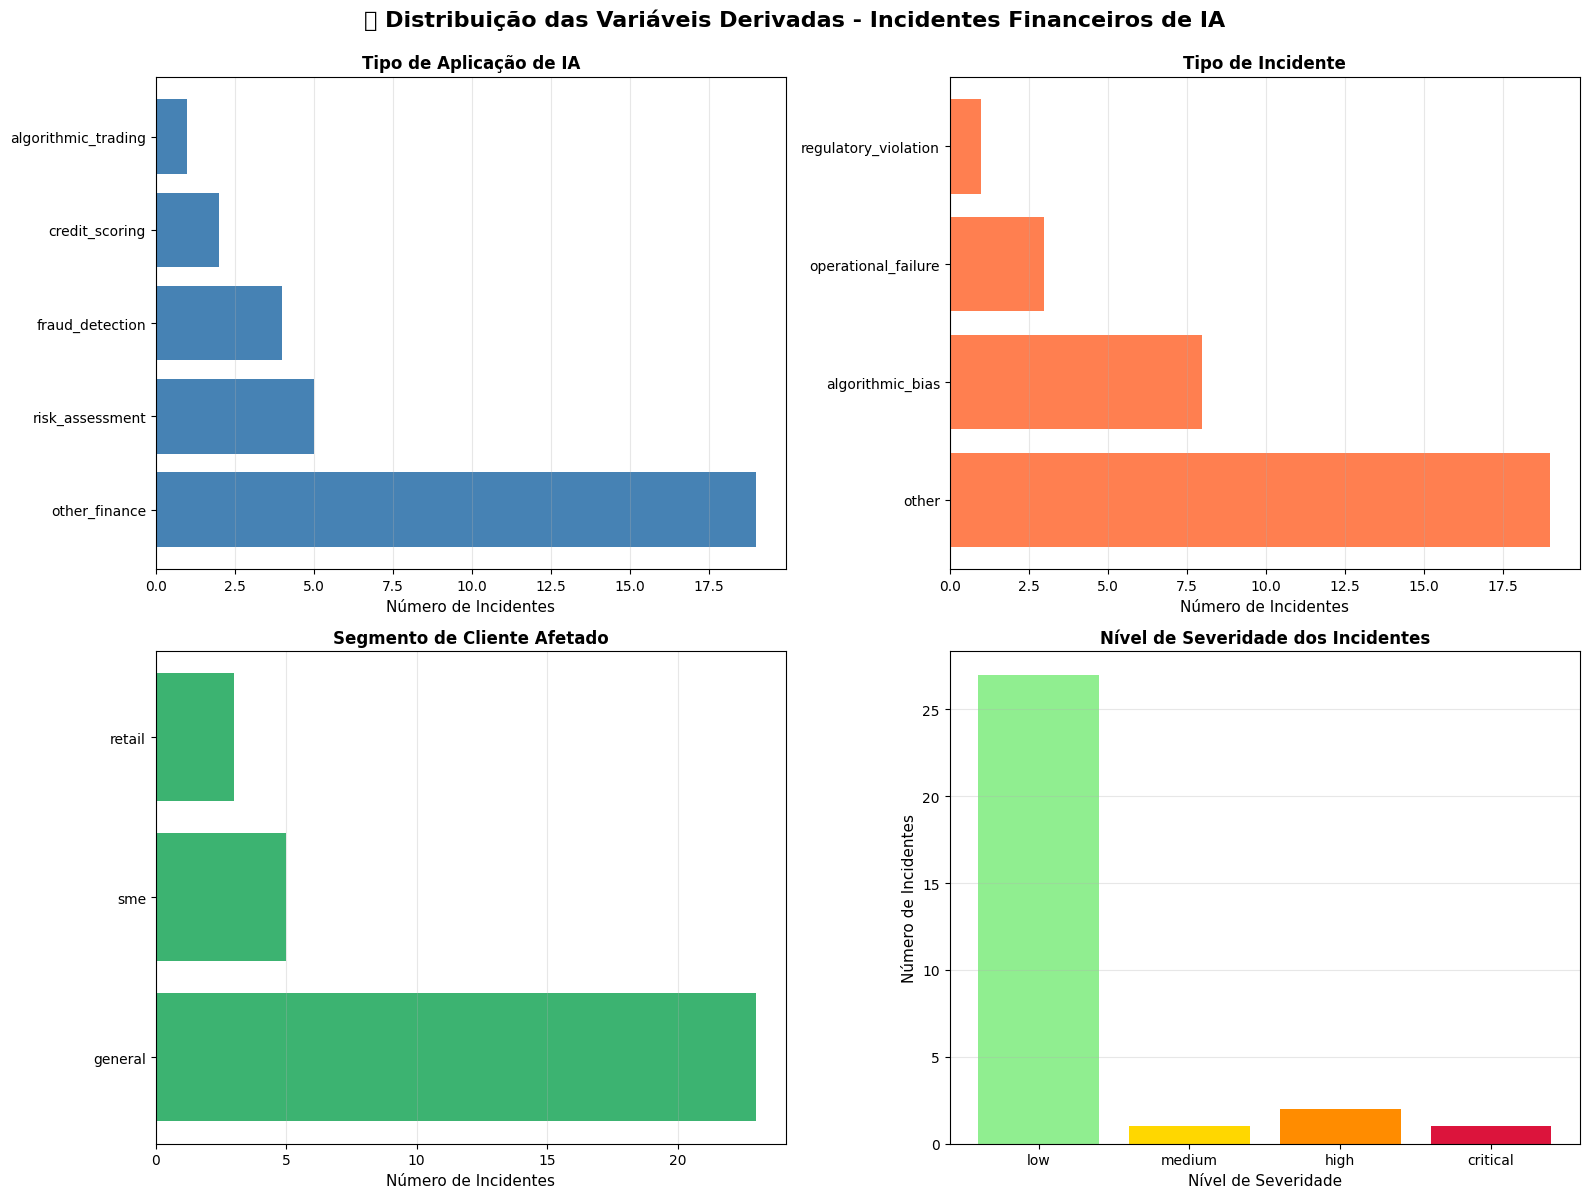

✅ Visualizações criadas com sucesso!


In [51]:
# Criando visualizações das features
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('📊 Distribuição das Variáveis Derivadas - Incidentes Financeiros de IA', 
             fontsize=16, fontweight='bold', y=0.995)

# 1. Application Type
app_counts = df_finance['application_type'].value_counts()
axes[0, 0].barh(app_counts.index, app_counts.values, color='steelblue')
axes[0, 0].set_xlabel('Número de Incidentes', fontsize=11)
axes[0, 0].set_title('Tipo de Aplicação de IA', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)

# 2. Incident Type
inc_counts = df_finance['incident_type'].value_counts()
axes[0, 1].barh(inc_counts.index, inc_counts.values, color='coral')
axes[0, 1].set_xlabel('Número de Incidentes', fontsize=11)
axes[0, 1].set_title('Tipo de Incidente', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='x', alpha=0.3)

# 3. Customer Segment
cust_counts = df_finance['customer_segment'].value_counts()
axes[1, 0].barh(cust_counts.index, cust_counts.values, color='mediumseagreen')
axes[1, 0].set_xlabel('Número de Incidentes', fontsize=11)
axes[1, 0].set_title('Segmento de Cliente Afetado', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)

# 4. Severity Level
sev_counts = df_finance['severity_level'].value_counts()
severity_order = ['low', 'medium', 'high', 'critical']
sev_counts = sev_counts.reindex(severity_order, fill_value=0)
colors = ['#90EE90', '#FFD700', '#FF8C00', '#DC143C']
axes[1, 1].bar(sev_counts.index, sev_counts.values, color=colors)
axes[1, 1].set_xlabel('Nível de Severidade', fontsize=11)
axes[1, 1].set_ylabel('Número de Incidentes', fontsize=11)
axes[1, 1].set_title('Nível de Severidade dos Incidentes', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Visualizações criadas com sucesso!")

## 💾 9. Salvamento do Dataset Processado

**O que faz**: Salva o dataset filtrado e com features criadas em um arquivo CSV.

**Caso de uso**: Este arquivo será usado nos próximos notebooks e pode ser compartilhado com stakeholders.

In [52]:
# Selecionando colunas finais
columns_to_save = [
    '_id', 'incident_id', 'occurred_date', 'title', 'summary',
    'deployer', 'developer', 'harmed_parties', 'reports',
    'year', 'text',
    'application_type', 'incident_type', 'customer_segment', 'severity_level',
    'regulatory_investigation', 'fine_imposed', 'policy_change', 'third_party_audit'
]

df_final = df_finance[columns_to_save].copy()

# Salvando em pasta com permissão de escrita
data_processed_dir = '/Users/fabicampanari/Desktop/ai-finance-project/3_Final_Running_Code/data/processed'
output_file = f'{data_processed_dir}/incidents_finance_filtered.csv'
df_final.to_csv(output_file, index=False)

print("="*80)
print("💾 DATASET SALVO COM SUCESSO")
print("="*80)
print(f"\n📁 Arquivo: {output_file}")
print(f"📊 Total de registros: {len(df_final):,}")
print(f"📋 Total de colunas: {len(df_final.columns)}")
print(f"\n✅ Dataset pronto para análise estatística e modelagem!")

💾 DATASET SALVO COM SUCESSO

📁 Arquivo: /Users/fabicampanari/Desktop/ai-finance-project/3_Final_Running_Code/data/processed/incidents_finance_filtered.csv
📊 Total de registros: 31
📋 Total de colunas: 19

✅ Dataset pronto para análise estatística e modelagem!


## 🗄️ 10. Criação do Banco de Dados SQLite

**O que faz**: Cria um banco de dados relacional SQLite com 3 tabelas inter-relacionadas:
1. **incidents**: Tabela principal com dados dos incidentes
2. **financial_impacts**: Dados sobre impactos financeiros (quando disponíveis)
3. **regulatory_responses**: Dados sobre respostas regulatórias e de governança

**Definição**: Um banco de dados relacional organiza dados em tabelas com relacionamentos definidos por chaves primárias e estrangeiras.

**Caso de uso**: 
- Requisito do projeto (mínimo 3 tabelas relacionadas)
- Permite consultas SQL complexas
- Base para a API RESTful
- Facilita manutenção e escalabilidade

In [53]:
# Conectando ao banco SQLite
# Usar caminho absoluto para evitar erro de permissão

import os
import sys

print("Current working directory:", os.getcwd())

# Novo caminho fixo para o banco de dados
# (sem fallback, sempre usa este path)
db_name = '/Users/fabicampanari/Desktop/ai-finance-project/3_Final_Running_Code/database/ai_finance_incidents.db'
# Garante que o diretório existe antes de conectar
os.makedirs(os.path.dirname(db_name), exist_ok=True)

def ensure_writable_dir(path):
    if not os.path.exists(path):
        try:
            os.makedirs(path, exist_ok=True)
        except Exception:
            return False
    return os.access(path, os.W_OK)

# --- Permissão antes de conectar ---
db_dir = os.path.dirname(db_name)
fallback_dir = os.path.expanduser('~/ai-finance-database')
fallback_db = os.path.join(fallback_dir, 'ai_finance_incidents.db')

# Testa permissão no diretório original
if not ensure_writable_dir(db_dir):
    print(f"[ERRO] Sem permissão de escrita no diretório do banco: {db_dir}")
    print(f"[AVISO] Usando diretório alternativo: {fallback_dir}")
    db_name = fallback_db
    ensure_writable_dir(fallback_dir)

# Testa permissão no arquivo do banco (se já existe)
if os.path.exists(db_name) and not os.access(db_name, os.W_OK):
    print(f"[ERRO] Sem permissão de escrita no arquivo do banco: {db_name}")
    print(f"[AVISO] Usando diretório alternativo: {fallback_dir}")
    db_name = fallback_db
    ensure_writable_dir(fallback_dir)

# Só conecta após garantir permissão
try:
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()
    print("Conexão com o banco de dados estabelecida com sucesso.")
except Exception:
    print(f"Erro ao conectar ao banco de dados.")
    sys.exit(1)

print("="*80)
print("🗄️ CRIANDO BANCO DE DADOS RELACIONAL")
print("="*80)
print(f"\n📁 Nome do banco: {db_name}")


Current working directory: /Users/fabicampanari/Desktop/ai-finance-project/3_Final_Running_Code/notebooks
[ERRO] Sem permissão de escrita no diretório do banco: /Users/fabicampanari/Desktop/ai-finance-project/3_Final_Running_Code/database
[AVISO] Usando diretório alternativo: /Users/fabicampanari/ai-finance-database
Conexão com o banco de dados estabelecida com sucesso.
🗄️ CRIANDO BANCO DE DADOS RELACIONAL

📁 Nome do banco: /Users/fabicampanari/ai-finance-database/ai_finance_incidents.db


In [54]:
# 10.1 - Criando TABELA 1: incidents (Principal)
# Ajuste robusto de permissão: tenta diretório original, senão usa fallback em HOME

db_dir = os.path.dirname(db_name)
fallback_dir = os.path.expanduser('~/ai-finance-database')
fallback_db = os.path.join(fallback_dir, 'ai_finance_incidents.db')

def ensure_writable_dir(path):
    if not os.path.exists(path):
        try:
            os.makedirs(path, exist_ok=True)
        except Exception as e:
            return False
    return os.access(path, os.W_OK)

# Testa permissão no diretório original
if not ensure_writable_dir(db_dir):
    print(f"[ERRO] Sem permissão de escrita no diretório do banco: {db_dir}")
    print(f"[AVISO] Usando diretório alternativo: {fallback_dir}")
    db_name = fallback_db
    ensure_writable_dir(fallback_dir)

# Testa permissão no arquivo do banco (se já existe)
if os.path.exists(db_name) and not os.access(db_name, os.W_OK):
    print(f"[ERRO] Sem permissão de escrita no arquivo do banco: {db_name}")
    print(f"[AVISO] Usando diretório alternativo: {fallback_dir}")
    db_name = fallback_db
    ensure_writable_dir(fallback_dir)

cursor.execute('''
DROP TABLE IF EXISTS incidents
''')

cursor.execute('''
CREATE TABLE incidents (
    incident_id INTEGER PRIMARY KEY,
    title TEXT NOT NULL,
    summary TEXT,
    occurred_date DATE,
    year INTEGER,
    deployer TEXT,
    developer TEXT,
    harmed_parties TEXT,
    application_type TEXT,
    customer_segment TEXT,
    incident_type TEXT,
    severity_level TEXT,
    text TEXT
)
''')

print("✅ Tabela 'incidents' criada")

✅ Tabela 'incidents' criada


In [55]:
# 10.2 - Criando TABELA 2: financial_impacts
cursor.execute('''
DROP TABLE IF EXISTS financial_impacts
''')

cursor.execute('''
CREATE TABLE financial_impacts (
    impact_id INTEGER PRIMARY KEY AUTOINCREMENT,
    incident_id INTEGER NOT NULL,
    severity_level TEXT,
    estimated_loss TEXT,
    impact_description TEXT,
    FOREIGN KEY (incident_id) REFERENCES incidents(incident_id)
)
''')

print("✅ Tabela 'financial_impacts' criada")

✅ Tabela 'financial_impacts' criada


In [56]:
# 10.3 - Criando TABELA 3: regulatory_responses
cursor.execute('''
DROP TABLE IF EXISTS regulatory_responses
''')

cursor.execute('''
CREATE TABLE regulatory_responses (
    response_id INTEGER PRIMARY KEY AUTOINCREMENT,
    incident_id INTEGER NOT NULL,
    regulatory_investigation INTEGER DEFAULT 0,
    fine_imposed INTEGER DEFAULT 0,
    policy_change INTEGER DEFAULT 0,
    third_party_audit INTEGER DEFAULT 0,
    response_description TEXT,
    FOREIGN KEY (incident_id) REFERENCES incidents(incident_id)
)
''')

print("✅ Tabela 'regulatory_responses' criada")
print("\n🏗️ Estrutura do banco criada com sucesso!")

✅ Tabela 'regulatory_responses' criada

🏗️ Estrutura do banco criada com sucesso!


In [57]:
# 10.4 - Populando a tabela 'incidents'
incidents_data = df_final[[
    'incident_id', 'title', 'summary', 'occurred_date', 'year',
    'deployer', 'developer', 'harmed_parties',
    'application_type', 'customer_segment', 'incident_type', 'severity_level', 'text'
]].copy()

# Convertendo datas para string
incidents_data['occurred_date'] = incidents_data['occurred_date'].astype(str)

incidents_data.to_sql('incidents', conn, if_exists='append', index=False)

print(f"✅ {len(incidents_data)} registros inseridos na tabela 'incidents'")

✅ 31 registros inseridos na tabela 'incidents'


In [58]:
# 10.5 - Populando a tabela 'financial_impacts'
financial_impacts_data = df_final[[
    'incident_id', 'severity_level'
]].copy()

financial_impacts_data['estimated_loss'] = 'Not reported'
financial_impacts_data['impact_description'] = df_final['summary'].str[:200]  # Primeiros 200 chars

financial_impacts_data.to_sql('financial_impacts', conn, if_exists='append', index=False)

print(f"✅ {len(financial_impacts_data)} registros inseridos na tabela 'financial_impacts'")

✅ 31 registros inseridos na tabela 'financial_impacts'


In [59]:
# 10.6 - Populando a tabela 'regulatory_responses'
regulatory_data = df_final[[
    'incident_id', 'regulatory_investigation', 'fine_imposed', 
    'policy_change', 'third_party_audit'
]].copy()

regulatory_data['response_description'] = 'Response data extracted from incident text'

regulatory_data.to_sql('regulatory_responses', conn, if_exists='append', index=False)

print(f"✅ {len(regulatory_data)} registros inseridos na tabela 'regulatory_responses'")

✅ 31 registros inseridos na tabela 'regulatory_responses'


In [60]:
# 10.7 - Verificando o banco criado
print("\n" + "="*80)
print("🔍 VERIFICAÇÃO DO BANCO DE DADOS")
print("="*80)

# Listando tabelas
cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
tables = cursor.fetchall()
print("\n📋 Tabelas criadas:")
for table in tables:
    print(f"  - {table[0]}")

# Contando registros
print("\n📊 Registros por tabela:")
for table in tables:
    cursor.execute(f"SELECT COUNT(*) FROM {table[0]}")
    count = cursor.fetchone()[0]
    print(f"  - {table[0]}: {count:,} registros")

# Exemplo de consulta JOIN
print("\n🔗 Exemplo de consulta JOIN:")
query = '''
SELECT 
    i.incident_id,
    i.title,
    i.severity_level,
    r.regulatory_investigation,
    r.fine_imposed
FROM incidents i
JOIN regulatory_responses r ON i.incident_id = r.incident_id
WHERE i.severity_level IN ('high', 'critical')
LIMIT 3
'''

result_df = pd.read_sql_query(query, conn)
display(result_df)

# Fechando conexão
conn.commit()
conn.close()

print("\n✅ Banco de dados criado e populado com sucesso!")
print(f"📁 Arquivo: {db_name}")


🔍 VERIFICAÇÃO DO BANCO DE DADOS

📋 Tabelas criadas:
  - incidents
  - financial_impacts
  - sqlite_sequence
  - regulatory_responses

📊 Registros por tabela:
  - incidents: 31 registros
  - financial_impacts: 31 registros
  - sqlite_sequence: 2 registros
  - regulatory_responses: 31 registros

🔗 Exemplo de consulta JOIN:


,incident_id,title,severity_level,regulatory_investigation,fine_imposed
0,57,Australian Automated Debt Assessment System Is...,high,0,0
1,425,State Farm Allegedly Discriminated against Bla...,high,0,0
2,516,ChatGPT Reportedly Exposed Users' Private Data...,critical,0,0



✅ Banco de dados criado e populado com sucesso!
📁 Arquivo: /Users/fabicampanari/ai-finance-database/ai_finance_incidents.db


## 📈 11. Resumo Final e Próximos Passos

**O que foi realizado neste notebook**:

✅ Carregamento do dataset AIID com milhares de incidentes  
✅ Análise exploratória inicial e avaliação de qualidade  
✅ Filtragem temática para incidentes do setor financeiro  
✅ Limpeza e padronização dos dados  
✅ Criação de 8 variáveis derivadas essenciais:  
   - application_type  
   - incident_type  
   - customer_segment  
   - severity_level  
   - 4 flags de governança  
✅ Visualização das distribuições  
✅ Salvamento do dataset processado  
✅ Criação de banco SQLite com 3 tabelas relacionadas  

**Próximos passos**:

➡️ **Notebook 2**: Análise Estatística e Testes de Hipóteses  
➡️ **Notebook 3**: Modelagem de Machine Learning  
➡️ **Notebook 4**: Desenvolvimento da API RESTful  

In [61]:
print("="*80)
print("🎉 NOTEBOOK 1 CONCLUÍDO COM SUCESSO!")
print("="*80)
print("\n📊 Estatísticas Finais:")
print(f"  • Total de incidentes financeiros: {len(df_final):,}")
print(f"  • Período coberto: {df_final['year'].min():.0f} - {df_final['year'].max():.0f}")
print(f"  • Tipos de aplicação: {df_final['application_type'].nunique()}")
print(f"  • Tipos de incidente: {df_final['incident_type'].nunique()}")
print(f"  • Segmentos de cliente: {df_final['customer_segment'].nunique()}")
print("\n📁 Arquivos gerados:")
print("  • incidents_finance_filtered.csv")
print("  • ai_finance_incidents.db")
print("\n➡️ Prossiga para o Notebook 2: Análise Estatística e Testes de Hipóteses")

🎉 NOTEBOOK 1 CONCLUÍDO COM SUCESSO!

📊 Estatísticas Finais:
  • Total de incidentes financeiros: 31
  • Período coberto: 2003 - 2023
  • Tipos de aplicação: 5
  • Tipos de incidente: 4
  • Segmentos de cliente: 3

📁 Arquivos gerados:
  • incidents_finance_filtered.csv
  • ai_finance_incidents.db

➡️ Prossiga para o Notebook 2: Análise Estatística e Testes de Hipóteses
